# Condition-Based Sketch Colourisation

**Pix2Pix-style Conditional GAN with sparse colour hint conditioning**

Name:Balaji Periyadurai-6962046 | Supervisor: Prof. Yi-Zhe Song 

---

### Before running this notebook

1. **Add the dataset**: click **+ Add Data** (right sidebar) → search `anime sketch colorization pair` → add the dataset by `ktaebum`.
2. **Enable GPU**: Settings (right sidebar) → Accelerator → **GPU T4 x2** or **P100**.
3. **Enable Internet**: Settings → Internet → **On** (only needed if installing pytorch-fid).
4. Run all cells in order, top to bottom.

This notebook trains for a **fixed time budget** (default 8.5 hours) and automatically
checkpoints, so it works safely within Kaggle's session limits. If training is not
finished when time runs out, save this notebook as a new **Version**, then in the next
session add your own previous Output as an input dataset and resume from the checkpoint.


In [3]:
# ── Imports ──────────────────────────────────────────────
import os
import sys
import glob
import time
import csv
import random
import shutil
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# ── Device check ─────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"PyTorch version : {torch.__version__}")
print(f"Device           : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU name         : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory (GB)  : {round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)}")
else:
    print("WARNING: No GPU detected. Go to Settings -> Accelerator -> GPU and restart.")


PyTorch version : 2.10.0+cu128
Device           : cuda
GPU name         : Tesla T4
GPU memory (GB)  : 15.6


## 1. Locate the Dataset

The Kaggle dataset stores each image as a **sketch and colour pair side by side**
in a single file. This cell finds every image automatically, wherever Kaggle mounted it,
so you don't need to know the exact folder path.

In [5]:
# ── Find all dataset images under /kaggle/input ──────────
candidate_files = []
for ext in ("*.png", "*.jpg", "*.jpeg"):
    candidate_files.extend(glob.glob(f"/kaggle/input/**/{ext}", recursive=True))

print(f"Found {len(candidate_files)} candidate image files under /kaggle/input")

if len(candidate_files) == 0:
    raise RuntimeError(
        "No images found. Did you add the dataset? "
        "Click '+ Add Data' (right sidebar) and search "
        "'anime sketch colorization pair' by ktaebum."
    )

# Show a few example paths so you can confirm it found the right dataset
for f in candidate_files[:3]:
    print(" ", f)

# Quick check: open the first image and report its size
sample_img = Image.open(candidate_files[0])
print(f"\nSample image size: {sample_img.size}  (should be roughly double-width, e.g. 1024x512)")


Found 35538 candidate image files under /kaggle/input
  /kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val/1924008.png
  /kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val/1242011.png
  /kaggle/input/datasets/ktaebum/anime-sketch-colorization-pair/data/val/2644052.png

Sample image size: (1024, 512)  (should be roughly double-width, e.g. 1024x512)


## 2. Set Up Output Directories

Everything we create (checkpoints, logs, figures) is written to `/kaggle/working/`,
which is the only writable location on Kaggle and is what gets saved as your
notebook's **Output** when you commit a version.

In [6]:
OUTPUT_ROOT   = "/kaggle/working"
CHECKPOINT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")
SAMPLE_DIR     = os.path.join(OUTPUT_ROOT, "samples")
FIGURE_DIR     = os.path.join(OUTPUT_ROOT, "figures")
LOG_DIR        = os.path.join(OUTPUT_ROOT, "logs")
EVAL_DIR       = os.path.join(OUTPUT_ROOT, "evaluation")

for d in [CHECKPOINT_DIR, SAMPLE_DIR, FIGURE_DIR, LOG_DIR, EVAL_DIR,
          os.path.join(EVAL_DIR, "generated"), os.path.join(EVAL_DIR, "real")]:
    os.makedirs(d, exist_ok=True)

print("Output directories ready under /kaggle/working/")


Output directories ready under /kaggle/working/


## 3. Train / Validation / Test Split

Rather than physically splitting and re-saving every image (which would double
your disk usage), we split the **file path list** itself. Each image is split
into its sketch and colour halves on the fly, inside the Dataset class below.

In [7]:
SEED = 42
random.seed(SEED)

shuffled = candidate_files[:]
random.shuffle(shuffled)

n = len(shuffled)
n_train = int(n * 0.8)
n_val   = int(n * 0.1)

train_files = shuffled[:n_train]
val_files   = shuffled[n_train:n_train + n_val]
test_files  = shuffled[n_train + n_val:]

print(f"Train : {len(train_files)} images")
print(f"Val   : {len(val_files)} images")
print(f"Test  : {len(test_files)} images")


Train : 28430 images
Val   : 3553 images
Test  : 3555 images


## 4. Dataset Class

Loads a combined sketch+colour image, splits it down the middle, generates a
sparse colour hint map (the conditioning signal), and returns a 7-channel
model input: `[sketch(3) + hint_map(3) + hint_mask(1)]`.

In [8]:
IMAGE_SIZE = 256
HINT_RATE  = 0.05   # 5% of pixels used as colour hints


def denormalise(tensor):
    """Converts a [-1,1] tensor back to a [0,255] uint8 numpy array (H,W,C)."""
    img = (tensor.detach().cpu().numpy() + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    if img.ndim == 3:
        return np.transpose(img, (1, 2, 0))
    elif img.ndim == 4:
        return np.transpose(img, (0, 2, 3, 1))
    return img


class SketchColourDataset(Dataset):
    """
    Loads a combined sketch|colour image, splits it, and builds the
    7-channel conditioned model input.
    """

    def __init__(self, file_paths, image_size=256, hint_rate=0.05, augment=False):
        self.file_paths = file_paths
        self.image_size = image_size
        self.hint_rate   = hint_rate
        self.augment     = augment

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        path = self.file_paths[idx]
        img = Image.open(path).convert("RGB")

        w, h = img.size
        mid = w // 2
        sketch = img.crop((0, 0, mid, h)).resize((self.image_size, self.image_size), Image.LANCZOS)
        colour = img.crop((mid, 0, w, h)).resize((self.image_size, self.image_size), Image.LANCZOS)

        if self.augment and random.random() > 0.5:
            sketch = TF.hflip(sketch)
            colour = TF.hflip(colour)

        sketch_np = np.array(sketch, dtype=np.float32)
        colour_np = np.array(colour, dtype=np.float32)

        hint_map, hint_mask = self._generate_hint_map(colour_np)

        sketch_t    = self._to_tensor(sketch_np)
        colour_t    = self._to_tensor(colour_np)
        hint_map_t  = self._to_tensor(hint_map)
        hint_mask_t = torch.from_numpy(hint_mask[np.newaxis, :, :].astype(np.float32))

        model_input = torch.cat([sketch_t, hint_map_t, hint_mask_t], dim=0)

        return {
            "input"    : model_input,
            "target"   : colour_t,
            "sketch"   : sketch_t,
            "hint_map" : hint_map_t,
            "name"     : os.path.basename(path),
        }

    def _generate_hint_map(self, colour_np):
        H, W, _ = colour_np.shape
        total = H * W
        n_hints = max(1, int(total * self.hint_rate))
        idx = np.random.choice(total, size=n_hints, replace=False)
        rows, cols = idx // W, idx % W

        hint_map  = np.zeros_like(colour_np)
        hint_mask = np.zeros((H, W), dtype=np.uint8)
        hint_map[rows, cols, :] = colour_np[rows, cols, :]
        hint_mask[rows, cols]   = 1
        return hint_map, hint_mask

    def _to_tensor(self, np_array):
        tensor = np_array / 127.5 - 1.0
        tensor = np.transpose(tensor, (2, 0, 1))
        return torch.from_numpy(tensor.copy()).float()


train_dataset = SketchColourDataset(train_files, IMAGE_SIZE, HINT_RATE, augment=True)
val_dataset   = SketchColourDataset(val_files,   IMAGE_SIZE, HINT_RATE, augment=False)
test_dataset  = SketchColourDataset(test_files,  IMAGE_SIZE, HINT_RATE, augment=False)

print(f"Datasets ready: train={len(train_dataset)}, val={len(val_dataset)}, test={len(test_dataset)}")


Datasets ready: train=28430, val=3553, test=3555


## 5. Sanity Check — View One Sample

Confirms the sketch, hint map, and ground truth are correctly paired before
spending any GPU time on training.

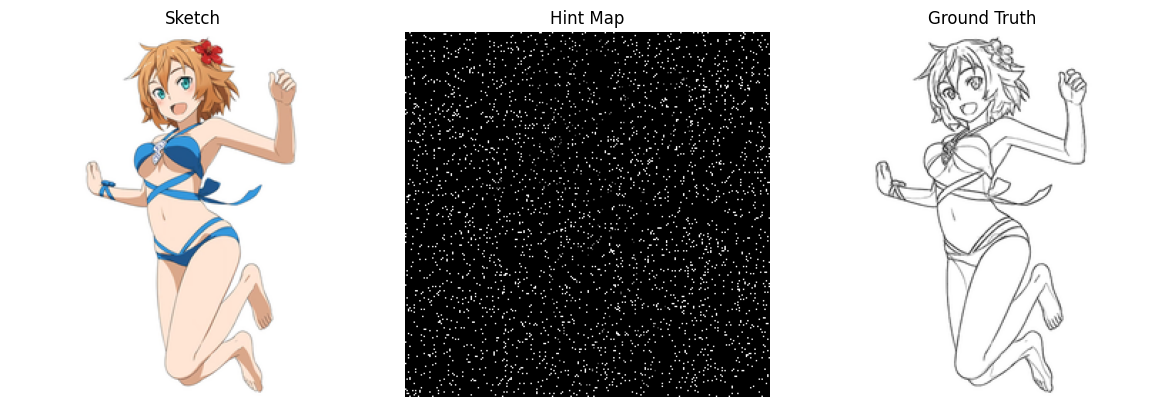

In [9]:
sample = train_dataset[0]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(denormalise(sample["sketch"]));    axes[0].set_title("Sketch");    axes[0].axis("off")
axes[1].imshow(denormalise(sample["hint_map"]));  axes[1].set_title("Hint Map");  axes[1].axis("off")
axes[2].imshow(denormalise(sample["target"]));    axes[2].set_title("Ground Truth"); axes[2].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "dataset_sample_check.png"), dpi=120)
plt.show()


## 6. Generator — U-Net

7-channel input (sketch + hints + mask) → 3-channel colourised output.
Skip connections preserve the sketch's structural detail.

In [10]:
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, use_batchnorm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=not use_batchnorm)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class DecoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, dropout=False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_ch, out_ch, 4, 2, 1, bias=False),
            nn.BatchNorm2d(out_ch),
        ]
        if dropout:
            layers.append(nn.Dropout(0.5))
        layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class UNetGenerator(nn.Module):
    def __init__(self, in_channels=7, out_channels=3, ngf=64):
        super().__init__()
        self.enc1 = EncoderBlock(in_channels, ngf,     use_batchnorm=False)
        self.enc2 = EncoderBlock(ngf,         ngf * 2)
        self.enc3 = EncoderBlock(ngf * 2,     ngf * 4)
        self.enc4 = EncoderBlock(ngf * 4,     ngf * 8)
        self.enc5 = EncoderBlock(ngf * 8,     ngf * 8)
        self.enc6 = EncoderBlock(ngf * 8,     ngf * 8)
        self.enc7 = EncoderBlock(ngf * 8,     ngf * 8)
        self.enc8 = EncoderBlock(ngf * 8,     ngf * 8)

        self.dec1 = DecoderBlock(ngf * 8,     ngf * 8, dropout=True)
        self.dec2 = DecoderBlock(ngf * 8 * 2, ngf * 8, dropout=True)
        self.dec3 = DecoderBlock(ngf * 8 * 2, ngf * 8, dropout=True)
        self.dec4 = DecoderBlock(ngf * 8 * 2, ngf * 8)
        self.dec5 = DecoderBlock(ngf * 8 * 2, ngf * 4)
        self.dec6 = DecoderBlock(ngf * 4 * 2, ngf * 2)
        self.dec7 = DecoderBlock(ngf * 2 * 2, ngf)

        self.output_layer = nn.Sequential(
            nn.ConvTranspose2d(ngf * 2, out_c[3/6] Starting training...
Epoch [  1/50]
Traceback (most recent call last):                                                                                                                                                                                                                               
  File "/scratch/bp/project/baseline-model.py", line 480, in <module>
    d_loss, g_adv, g_l1, g_total = train_one_epoch(
                                   ^^^^^^^^^^^^^^^^
  File "/scratch/bp/project/baseline-model.py", line 397, in train_one_epoch
    for batch in pbar:
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/tqdm/std.py", line 1187, in __iter__
    for obj in iterable:
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 725, in __next__
    data = self._next_data()
           ^^^^^^^^^^^^^^^^^
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1529, in _next_data
    return self._process_data(data, worker_id)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1567, in _process_data
    data.reraise()
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/_utils.py", line 794, in reraise
    raise exception
FileNotFoundError: Caught FileNotFoundError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/utils/data/_utils/worker.py", line 374, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
           ^^^^^^^^^^^^^^^^^^^^
  File "/user/HS400/bp00798/.local/lib/python3.12/site-packages/torch/utils/data/_utils/fetch.py", line 54, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/scratch/bp/project/baseline-model.py", line 140, in __getitem__
    sketch = Image.open(os.path.join(self.sketch_dir, name + ".png")).convert("RGB")
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3/dist-packages/PIL/Image.py", line 3247, in open
    fp = builtins.open(filename, "rb")
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
FileNotFoundError: [Errno 2] No such file or directory: '/scratch/bp/project/archive/data/data/train/1987057.png.png'hannels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        e1 = self.enc1(x); e2 = self.enc2(e1); e3 = self.enc3(e2); e4 = self.enc4(e3)
        e5 = self.enc5(e4); e6 = self.enc6(e5); e7 = self.enc7(e6); e8 = self.enc8(e7)

        d1 = self.dec1(e8)
        d2 = self.dec2(torch.cat([d1, e7], 1))
        d3 = self.dec3(torch.cat([d2, e6], 1))
        d4 = self.dec4(torch.cat([d3, e5], 1))
        d5 = self.dec5(torch.cat([d4, e4], 1))
        d6 = self.dec6(torch.cat([d5, e3], 1))
        d7 = self.dec7(torch.cat([d6, e2], 1))
        return self.output_layer(torch.cat([d7, e1], 1))


# Quick test
_test_in = torch.randn(2, 7, 256, 256)
_G_test = UNetGenerator()
_test_out = _G_test(_test_in)
print(f"Generator test  : input {_test_in.shape} -> output {_test_out.shape}")
print(f"Generator params: {sum(p.numel() for p in _G_test.parameters()):,}")
del _G_test, _test_in, _test_out


Generator test  : input torch.Size([2, 7, 256, 256]) -> output torch.Size([2, 3, 256, 256])
Generator params: 54,419,139


## 7. Discriminator — PatchGAN

Evaluates 70×70 patches of the (sketch, colour) pair as real or fake,
producing a 30×30 grid of scores.

In [11]:
class DiscriminatorBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=2, use_batchnorm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, stride, 1, bias=not use_batchnorm)]
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class PatchGANDiscriminator(nn.Module):
    def __init__(self, in_channels=6, ndf=64):
        super().__init__()
        self.layer1 = DiscriminatorBlock(in_channels, ndf,     stride=2, use_batchnorm=False)
        self.layer2 = DiscriminatorBlock(ndf,         ndf * 2, stride=2)
        self.layer3 = DiscriminatorBlock(ndf * 2,     ndf * 4, stride=2)
        self.layer4 = DiscriminatorBlock(ndf * 4,     ndf * 8, stride=1)
        self.output = nn.Conv2d(ndf * 8, 1, 4, 1, 1)

    def forward(self, sketch, colour):
        x = torch.cat([sketch, colour], dim=1)
        x = self.layer1(x); x = self.layer2(x); x = self.layer3(x); x = self.layer4(x)
        return self.output(x)


# Quick test
_s = torch.randn(2, 3, 256, 256)
_c = torch.randn(2, 3, 256, 256)
_D_test = PatchGANDiscriminator()
_out = _D_test(_s, _c)
print(f"Discriminator test : output {_out.shape}")
print(f"Discriminator params: {sum(p.numel() for p in _D_test.parameters()):,}")
del _D_test, _s, _c, _out


Discriminator test : output torch.Size([2, 1, 30, 30])
Discriminator params: 2,768,705


## 8. Loss Functions

Adversarial loss (BCE on PatchGAN output) + L1 pixel reconstruction loss,
combined as `L_G = L_adv + λ·L1` with λ=100.

In [12]:
class GANLoss(nn.Module):
    def __init__(self, device):
        super().__init__()
        self.device  = device
        self.loss_fn = nn.BCEWithLogitsLoss()

    def _labels(self, preds, is_real):
        return torch.full_like(preds, 1.0 if is_real else 0.0, device=self.device)

    def discriminator_loss(self, real_output, fake_output):
        real_labels = self._labels(real_output, True)
        fake_labels = self._labels(fake_output, False)
        return (self.loss_fn(real_output, real_labels) + self.loss_fn(fake_output, fake_labels)) * 0.5

    def generator_adversarial_loss(self, fake_output):
        real_labels = self._labels(fake_output, True)
        return self.loss_fn(fake_output, real_labels)


class L1Loss(nn.Module):
    def __init__(self):
        super().__init__()
        self.loss_fn = nn.L1Loss()

    def forward(self, generated, target):
        return self.loss_fn(generated, target)


## 9. Configuration

Tuned for a typical Kaggle GPU (T4 16GB or P100 16GB). Adjust `BATCH_SIZE`
down to 4 if you hit an out-of-memory error.

**Time budget**: Kaggle GPU sessions are limited (commonly ~9–12 hours).
`TRAIN_TIME_LIMIT_HOURS` stops training safely before the session is killed,
saving a final checkpoint you can resume from in your next session.

In [13]:
BATCH_SIZE     = 8
NUM_EPOCHS     = 10          # upper bound; time limit below usually governs
LEARNING_RATE  = 2e-4
BETA1, BETA2   = 0.5, 0.999
LAMBDA_L1      = 100.0
NGF, NDF       = 64, 64

SAVE_EVERY           = 5      # epochs between checkpoint saves
SAMPLE_EVERY         = 2      # epochs between sample image saves
NUM_SAMPLE_IMAGES    = 4

TRAIN_TIME_LIMIT_HOURS = 8.5  # stop safely before Kaggle kills the session

print("Configuration set.")
print(f"  Batch size : {BATCH_SIZE}")
print(f"  Max epochs : {NUM_EPOCHS}")
print(f"  Time limit : {TRAIN_TIME_LIMIT_HOURS} hours")


Configuration set.
  Batch size : 8
  Max epochs : 10
  Time limit : 8.5 hours


In [14]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, pin_memory=(DEVICE == "cuda"))
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=2, pin_memory=(DEVICE == "cuda"))
test_loader  = DataLoader(test_dataset,  batch_size=1,          shuffle=False,
                           num_workers=2, pin_memory=(DEVICE == "cuda"))

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Test images: {len(test_dataset)}")


Train batches: 3554  |  Val batches: 445  |  Test images: 3555


## 10. Build Models

If a checkpoint already exists in `/kaggle/working/checkpoints/` (for example,
because you added a previous session's Output as an input dataset and copied
it in), training resumes automatically from the latest one.

In [15]:
def init_weights(model):
    for m in model.modules():
        if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.normal_(m.weight.data, 0.0, 0.02)
            if m.bias is not None:
                nn.init.constant_(m.bias.data, 0)
        elif isinstance(m, nn.BatchNorm2d):
            nn.init.normal_(m.weight.data, 1.0, 0.02)
            nn.init.constant_(m.bias.data, 0)


device = torch.device(DEVICE)

G = UNetGenerator(in_channels=7, out_channels=3, ngf=NGF).to(device)
D = PatchGANDiscriminator(in_channels=6, ndf=NDF).to(device)

opt_G = torch.optim.Adam(G.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))
opt_D = torch.optim.Adam(D.parameters(), lr=LEARNING_RATE, betas=(BETA1, BETA2))

gan_loss = GANLoss(device=device)
l1_loss  = L1Loss()

start_epoch = 1
loss_history = []

# ── Resume from checkpoint if one exists ─────────────────
existing_ckpts = sorted(glob.glob(os.path.join(CHECKPOINT_DIR, "epoch_*.pth")))
if existing_ckpts:
    latest = existing_ckpts[-1]
    print(f"Found existing checkpoint: {latest}  -> resuming")
    ckpt = torch.load(latest, map_location=device)
    G.load_state_dict(ckpt["G_state"])
    D.load_state_dict(ckpt["D_state"])
    opt_G.load_state_dict(ckpt["opt_G_state"])
    opt_D.load_state_dict(ckpt["opt_D_state"])
    start_epoch = ckpt["epoch"] + 1
    loss_history = ckpt.get("loss_log", [])
    print(f"Resuming from epoch {start_epoch}")
else:
    print("No checkpoint found. Initialising fresh weights.")
    init_weights(G)
    init_weights(D)

print(f"Generator params     : {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params : {sum(p.numel() for p in D.parameters()):,}")


No checkpoint found. Initialising fresh weights.
Generator params     : 54,419,139
Discriminator params : 2,768,705


## 11. Training Functions

In [17]:
def train_one_epoch(G, D, loader, opt_G, opt_D, gan_loss, l1_loss, device):
    G.train(); D.train()
    sums = {"d": 0.0, "g_adv": 0.0, "g_l1": 0.0, "g_total": 0.0}

    pbar = tqdm(loader, desc="  Training", leave=False)
    for batch in pbar:
        model_input = batch["input"].to(device)
        target      = batch["target"].to(device)
        sketch      = batch["sketch"].to(device)

        fake_colour = G(model_input)

        # Discriminator update
        for p in D.parameters(): p.requires_grad = True
        opt_D.zero_grad()
        real_out = D(sketch, target)
        fake_out = D(sketch, fake_colour.detach())
        d_loss = gan_loss.discriminator_loss(real_out, fake_out)
        d_loss.backward()
        opt_D.step()

        # Generator update
        for p in D.parameters(): p.requires_grad = False
        opt_G.zero_grad()
        fake_out_g = D(sketch, fake_colour)
        g_adv = gan_loss.generator_adversarial_loss(fake_out_g)
        g_l1  = l1_loss(fake_colour, target)
        g_total = g_adv + LAMBDA_L1 * g_l1
        g_total.backward()
        opt_G.step()

        sums["d"] += d_loss.item(); sums["g_adv"] += g_adv.item()
        sums["g_l1"] += g_l1.item(); sums["g_total"] += g_total.item()
        pbar.set_postfix({"D": f"{d_loss.item():.3f}", "G_L1": f"{g_l1.item():.4f}"})

    n = len(loader)
    return sums["d"]/n, sums["g_adv"]/n, sums["g_l1"]/n, sums["g_total"]/n


def save_sample_grid(G, val_loader, epoch, device, out_dir):
    G.eval()
    batch = next(iter(val_loader))
    model_input = batch["input"].to(device)
    target      = batch["target"].to(device)
    sketch, hint_map = batch["sketch"], batch["hint_map"]

    with torch.no_grad():
        generated = G(model_input)

    n = min(NUM_SAMPLE_IMAGES, model_input.size(0))
    rows = []
    for i in range(n):
        row = np.concatenate([
            denormalise(sketch[i]), denormalise(hint_map[i]),
            denormalise(generated[i]), denormalise(target[i])
        ], axis=1)
        rows.append(row)
    grid = np.concatenate(rows, axis=0)

    path = os.path.join(out_dir, f"epoch_{epoch:04d}.png")
    Image.fromarray(grid).save(path)
    G.train()
    return path


def save_checkpoint(G, D, opt_G, opt_D, epoch, loss_log, path):
    torch.save({
        "epoch": epoch, "G_state": G.state_dict(), "D_state": D.state_dict(),
        "opt_G_state": opt_G.state_dict(), "opt_D_state": opt_D.state_dict(),
        "loss_log": loss_log,
    }, path)


## 12. Run Training

Trains until `NUM_EPOCHS` is reached **or** `TRAIN_TIME_LIMIT_HOURS` elapses,
whichever comes first. Saves a checkpoint and sample grid periodically, and
always saves a final checkpoint at the end so you never lose progress.

In [18]:
csv_path = os.path.join(LOG_DIR, "training_losses.csv")
if start_epoch == 1:
    with open(csv_path, "w", newline="") as f:
        csv.writer(f).writerow(["epoch", "d_loss", "g_adv_loss", "g_l1_loss", "g_total_loss"])

start_time = time.time()
time_limit_seconds = TRAIN_TIME_LIMIT_HOURS * 3600

for epoch in range(start_epoch, NUM_EPOCHS + 1):
    elapsed_hours = (time.time() - start_time) / 3600
    if time.time() - start_time > time_limit_seconds:
        print(f"\nTime limit of {TRAIN_TIME_LIMIT_HOURS}h reached after epoch {epoch-1}. Stopping safely.")
        break

    print(f"Epoch [{epoch:>3}/{NUM_EPOCHS}]  (elapsed: {elapsed_hours:.2f}h)")

    d_loss, g_adv, g_l1, g_total = train_one_epoch(
        G, D, train_loader, opt_G, opt_D, gan_loss, l1_loss, device
    )
    print(f"  D={d_loss:.4f}  G_adv={g_adv:.4f}  G_L1={g_l1:.4f}  G_total={g_total:.4f}")

    with open(csv_path, "a", newline="") as f:
        csv.writer(f).writerow([epoch, f"{d_loss:.6f}", f"{g_adv:.6f}", f"{g_l1:.6f}", f"{g_total:.6f}"])

    loss_history.append({"epoch": epoch, "d_loss": d_loss, "g_adv": g_adv, "g_l1": g_l1, "g_total": g_total})

    if epoch % SAMPLE_EVERY == 0 or epoch == 1:
        path = save_sample_grid(G, val_loader, epoch, device, SAMPLE_DIR)
        print(f"  Sample saved -> {path}")

    if epoch % SAVE_EVERY == 0 or epoch == NUM_EPOCHS:
        ckpt_path = os.path.join(CHECKPOINT_DIR, f"epoch_{epoch:04d}.pth")
        save_checkpoint(G, D, opt_G, opt_D, epoch, loss_history, ckpt_path)
        print(f"  Checkpoint saved -> {ckpt_path}")

# Always save a final checkpoint, whether finished or stopped by time limit
final_path = os.path.join(CHECKPOINT_DIR, "final_model.pth")
save_checkpoint(G, D, opt_G, opt_D, epoch, loss_history, final_path)
print(f"\nFinal model saved -> {final_path}")


Epoch [  1/10]  (elapsed: 0.00h)


  Training:   0%|          | 0/3554 [00:00<?, ?it/s]

  D=0.5858  G_adv=1.1837  G_L1=0.0602  G_total=7.2058
  Sample saved -> /kaggle/working/samples/epoch_0001.png
Epoch [  2/10]  (elapsed: 0.31h)


  Training:   0%|          | 0/3554 [00:00<?, ?it/s]

  D=0.6690  G_adv=0.8127  G_L1=0.0334  G_total=4.1514
  Sample saved -> /kaggle/working/samples/epoch_0002.png
Epoch [  3/10]  (elapsed: 0.61h)


...

  D=0.6727  G_adv=0.8028  G_L1=0.0285  G_total=3.6564
  Sample saved -> /kaggle/working/samples/epoch_0008.png
Epoch [  9/10]  (elapsed: 2.45h)


  Training:   0%|          | 0/3554 [00:00<?, ?it/s]

  D=0.6726  G_adv=0.8063  G_L1=0.0284  G_total=3.6505
Epoch [ 10/10]  (elapsed: 2.76h)


  Training:   0%|          | 0/3554 [00:00<?, ?it/s]

  D=0.6721  G_adv=0.8102  G_L1=0.0284  G_total=3.6485
  Sample saved -> /kaggle/working/samples/epoch_0010.png
  Checkpoint saved -> /kaggle/working/checkpoints/epoch_0010.pth

Final model saved -> /kaggle/working/checkpoints/final_model.pth


## 13. Plot Training Loss Curves

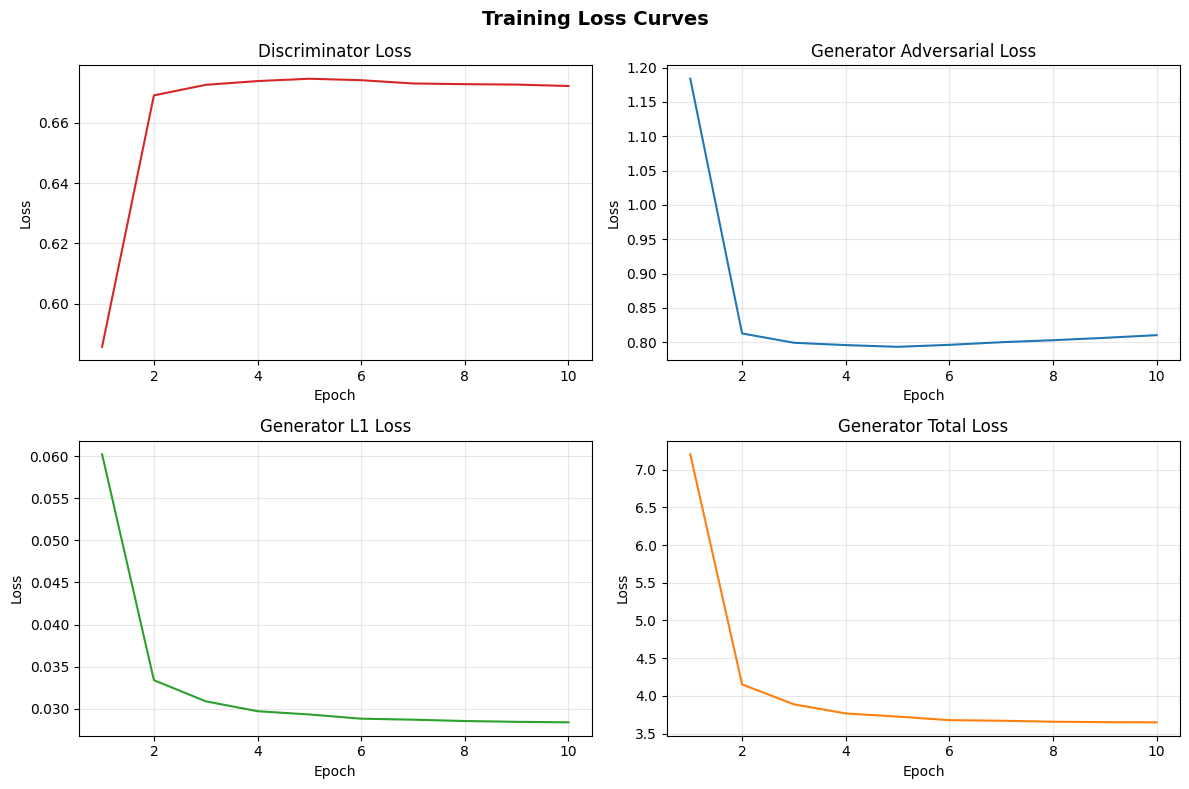

In [19]:
epochs_l, d_l, gadv_l, gl1_l, gtot_l = [], [], [], [], []
with open(csv_path, "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        epochs_l.append(int(row["epoch"]))
        d_l.append(float(row["d_loss"]))
        gadv_l.append(float(row["g_adv_loss"]))
        gl1_l.append(float(row["g_l1_loss"]))
        gtot_l.append(float(row["g_total_loss"]))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Training Loss Curves", fontsize=14, fontweight="bold")
plots = [
    (axes[0,0], d_l,    "Discriminator Loss",       "tab:red"),
    (axes[0,1], gadv_l, "Generator Adversarial Loss","tab:blue"),
    (axes[1,0], gl1_l,  "Generator L1 Loss",         "tab:green"),
    (axes[1,1], gtot_l, "Generator Total Loss",      "tab:orange"),
]
for ax, values, title, colour in plots:
    ax.plot(epochs_l, values, color=colour, linewidth=1.5)
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_ROOT, "loss_curves.png"), dpi=150, bbox_inches="tight")
plt.show()


## 14. Quantitative Evaluation — PSNR & SSIM

(FID is optional and requires `pip install pytorch-fid` with Internet enabled —
see the optional cell at the end.)

In [20]:
from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity   as ssim_fn

G.eval()
all_psnr, all_ssim, per_image = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Evaluating"):
        model_input = batch["input"].to(device)
        target      = batch["target"].to(device)
        name        = batch["name"][0]

        generated = G(model_input)
        gen_np = denormalise(generated[0])
        tgt_np = denormalise(target[0])

        p = psnr_fn(tgt_np, gen_np, data_range=255)
        s = ssim_fn(tgt_np, gen_np, data_range=255, channel_axis=2)
        all_psnr.append(p); all_ssim.append(s)
        per_image.append({"name": name, "psnr": p, "ssim": s})

        Image.fromarray(gen_np).save(os.path.join(EVAL_DIR, "generated", f"{name}"))
        Image.fromarray(tgt_np).save(os.path.join(EVAL_DIR, "real", f"{name}"))

mean_psnr, std_psnr = np.mean(all_psnr), np.std(all_psnr)
mean_ssim, std_ssim = np.mean(all_ssim), np.std(all_ssim)

print(f"\nPSNR : {mean_psnr:.2f} +/- {std_psnr:.2f} dB")
print(f"SSIM : {mean_ssim:.4f} +/- {std_ssim:.4f}")

# Save CSV
with open(os.path.join(EVAL_DIR, "metrics_test.csv"), "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["name", "psnr", "ssim"])
    writer.writeheader()
    for row in per_image:
        writer.writerow({"name": row["name"], "psnr": f"{row['psnr']:.4f}", "ssim": f"{row['ssim']:.4f}"})

# Save summary
with open(os.path.join(EVAL_DIR, "summary_test.txt"), "w") as f:
    f.write(f"PSNR : {mean_psnr:.2f} +/- {std_psnr:.2f} dB\n")
    f.write(f"SSIM : {mean_ssim:.4f} +/- {std_ssim:.4f}\n")

print("\nSaved: evaluation/metrics_test.csv and evaluation/summary_test.txt")


Evaluating:   0%|          | 0/3555 [00:00<?, ?it/s]


PSNR : 26.96 +/- 1.91 dB
SSIM : 0.9419 +/- 0.0244

Saved: evaluation/metrics_test.csv and evaluation/summary_test.txt


## 14b. Optional — FID Score

Requires Internet to be **On** in notebook Settings. Skip if Internet is off
or this is slow; PSNR and SSIM are sufficient for the dissertation.

In [ ]:
# Uncomment to run:
# !pip install pytorch-fid --quiet
# from pytorch_fid import fid_score
# fid = fid_score.calculate_fid_given_paths(
#     [os.path.join(EVAL_DIR, "generated"), os.path.join(EVAL_DIR, "real")],
#     batch_size=32, device=DEVICE, dims=2048
# )
# print(f"FID: {fid:.2f}")
# with open(os.path.join(EVAL_DIR, "summary_test.txt"), "a") as f:
#     f.write(f"FID  : {fid:.2f}\n")


## 15. Visual Results — Dissertation Figures

Generates the main results grid, best cases, and failure cases for Chapter 5.

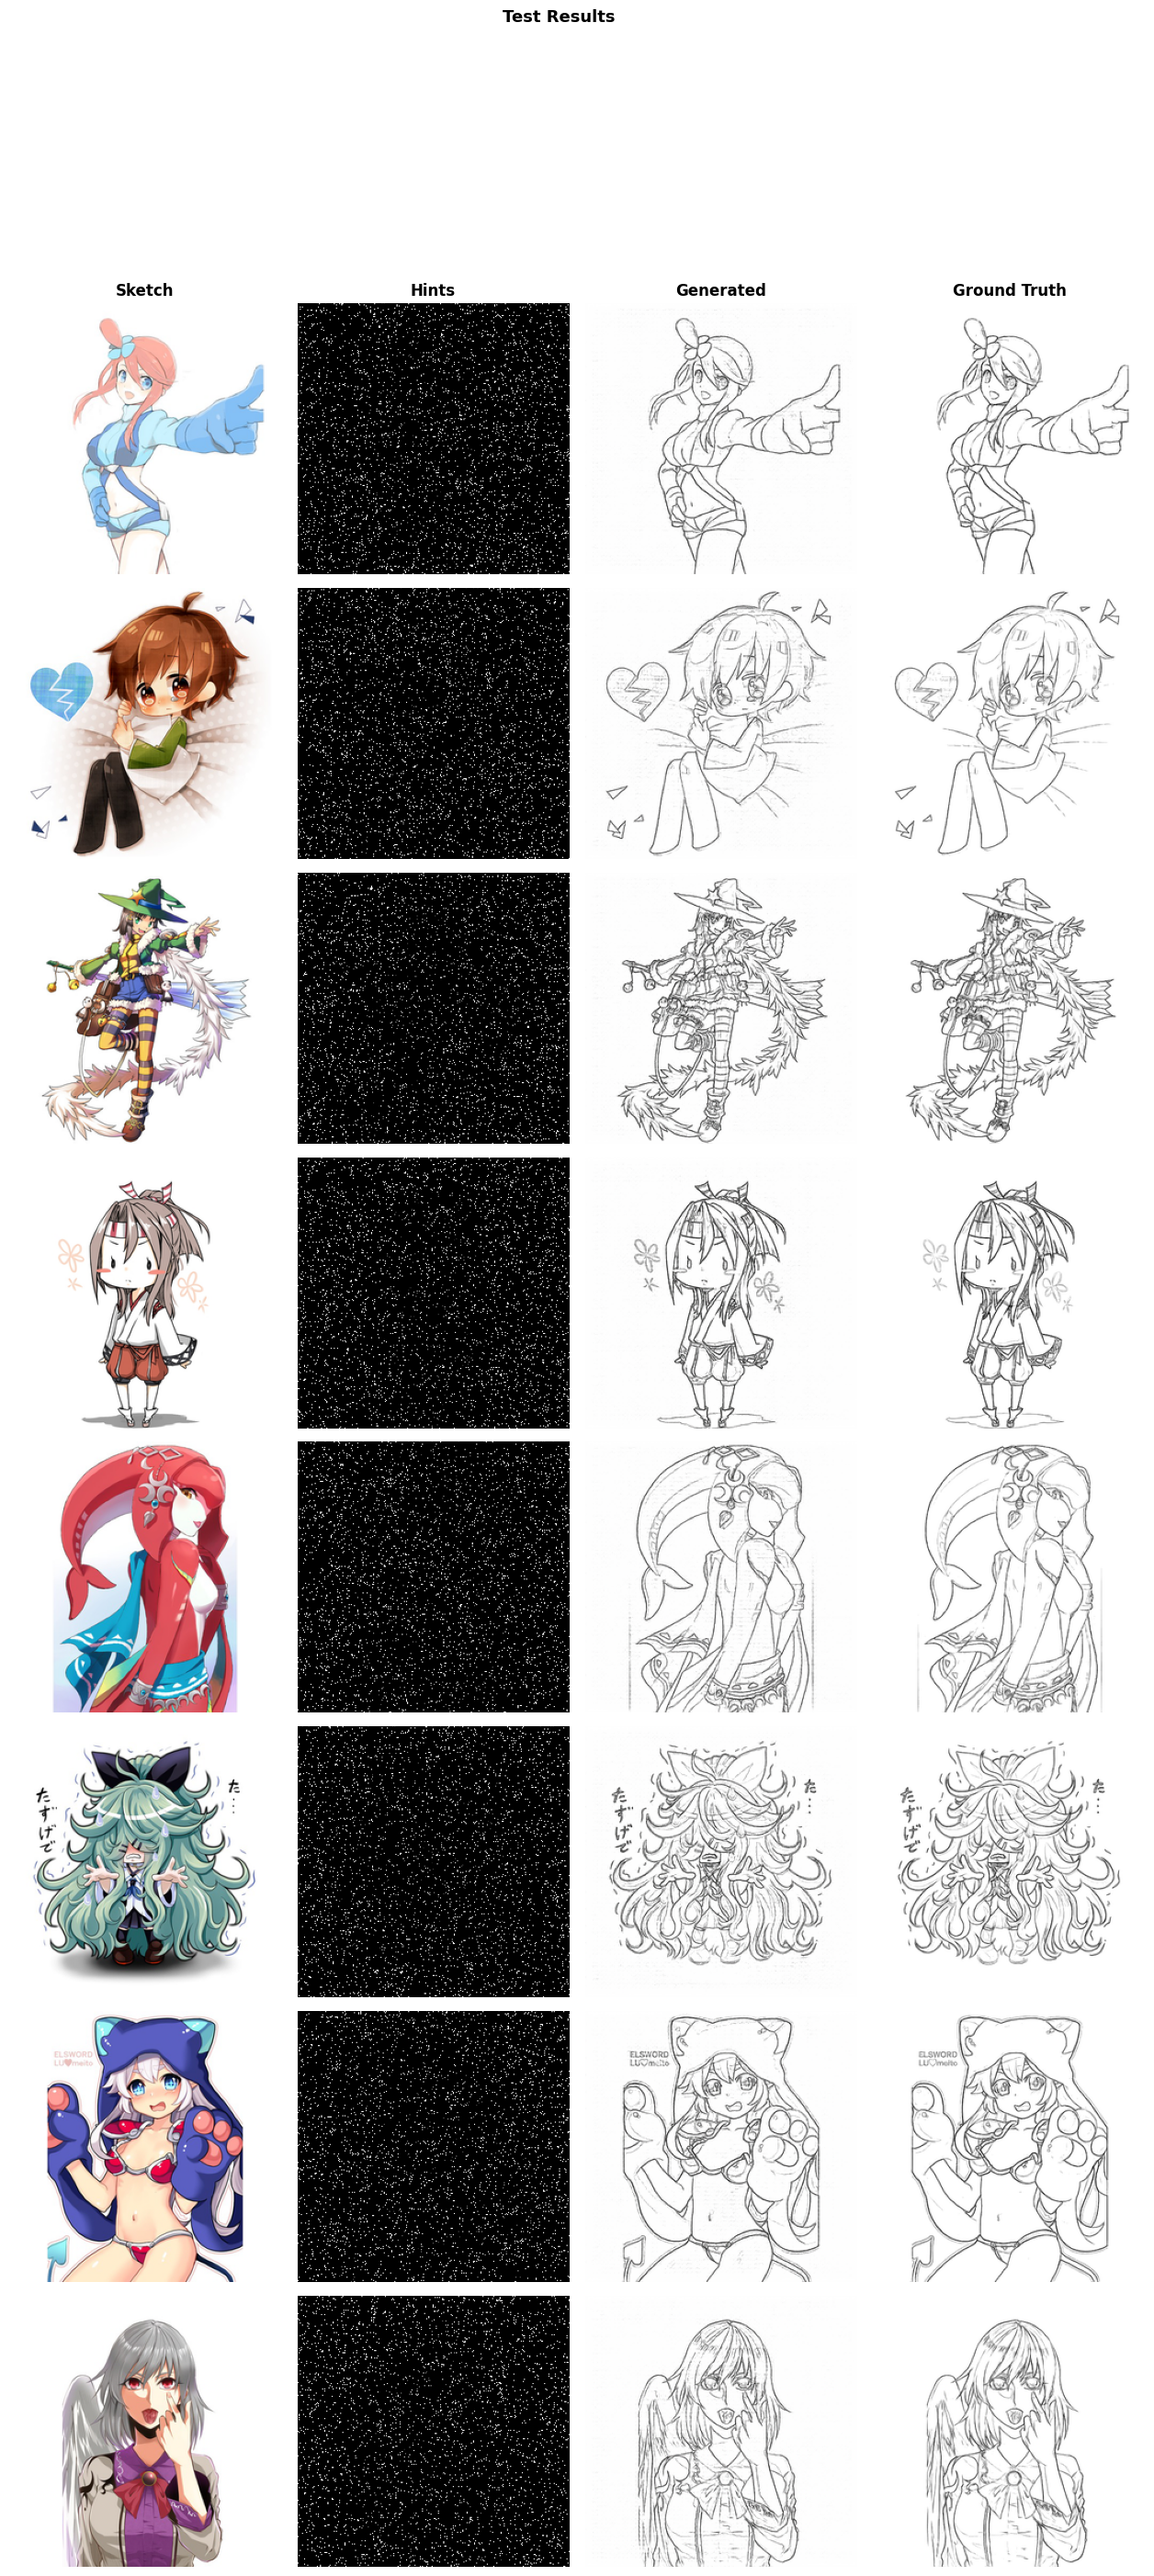

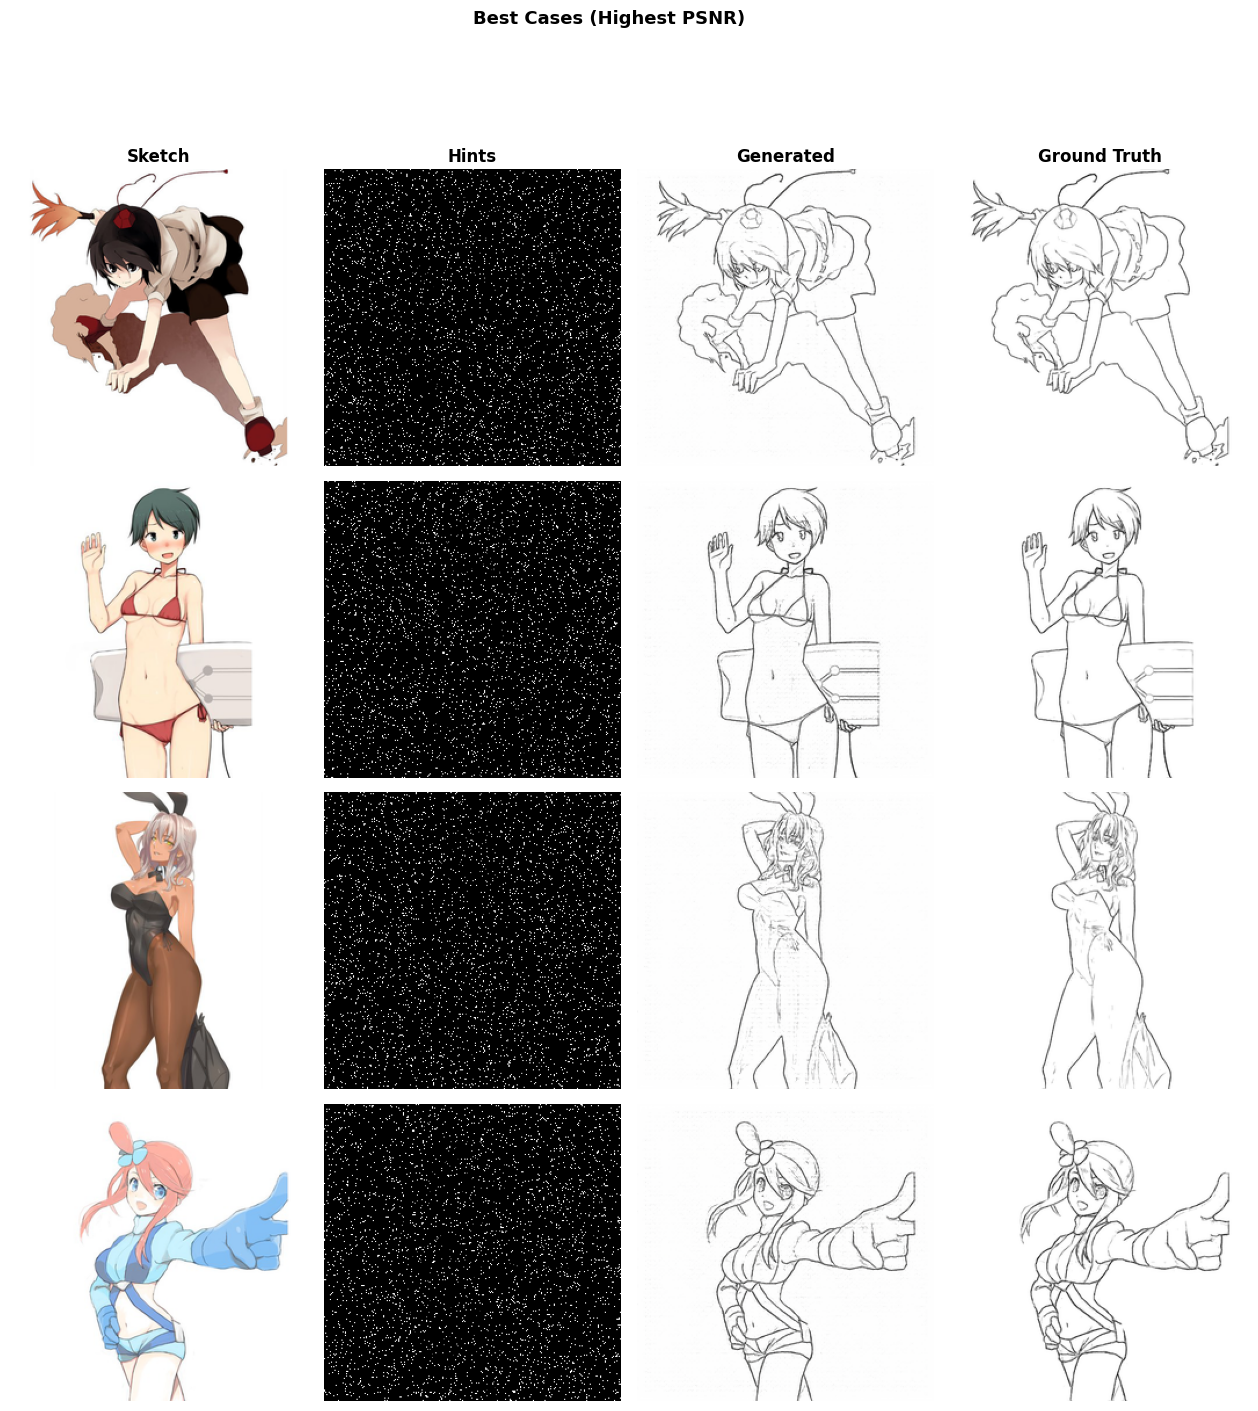

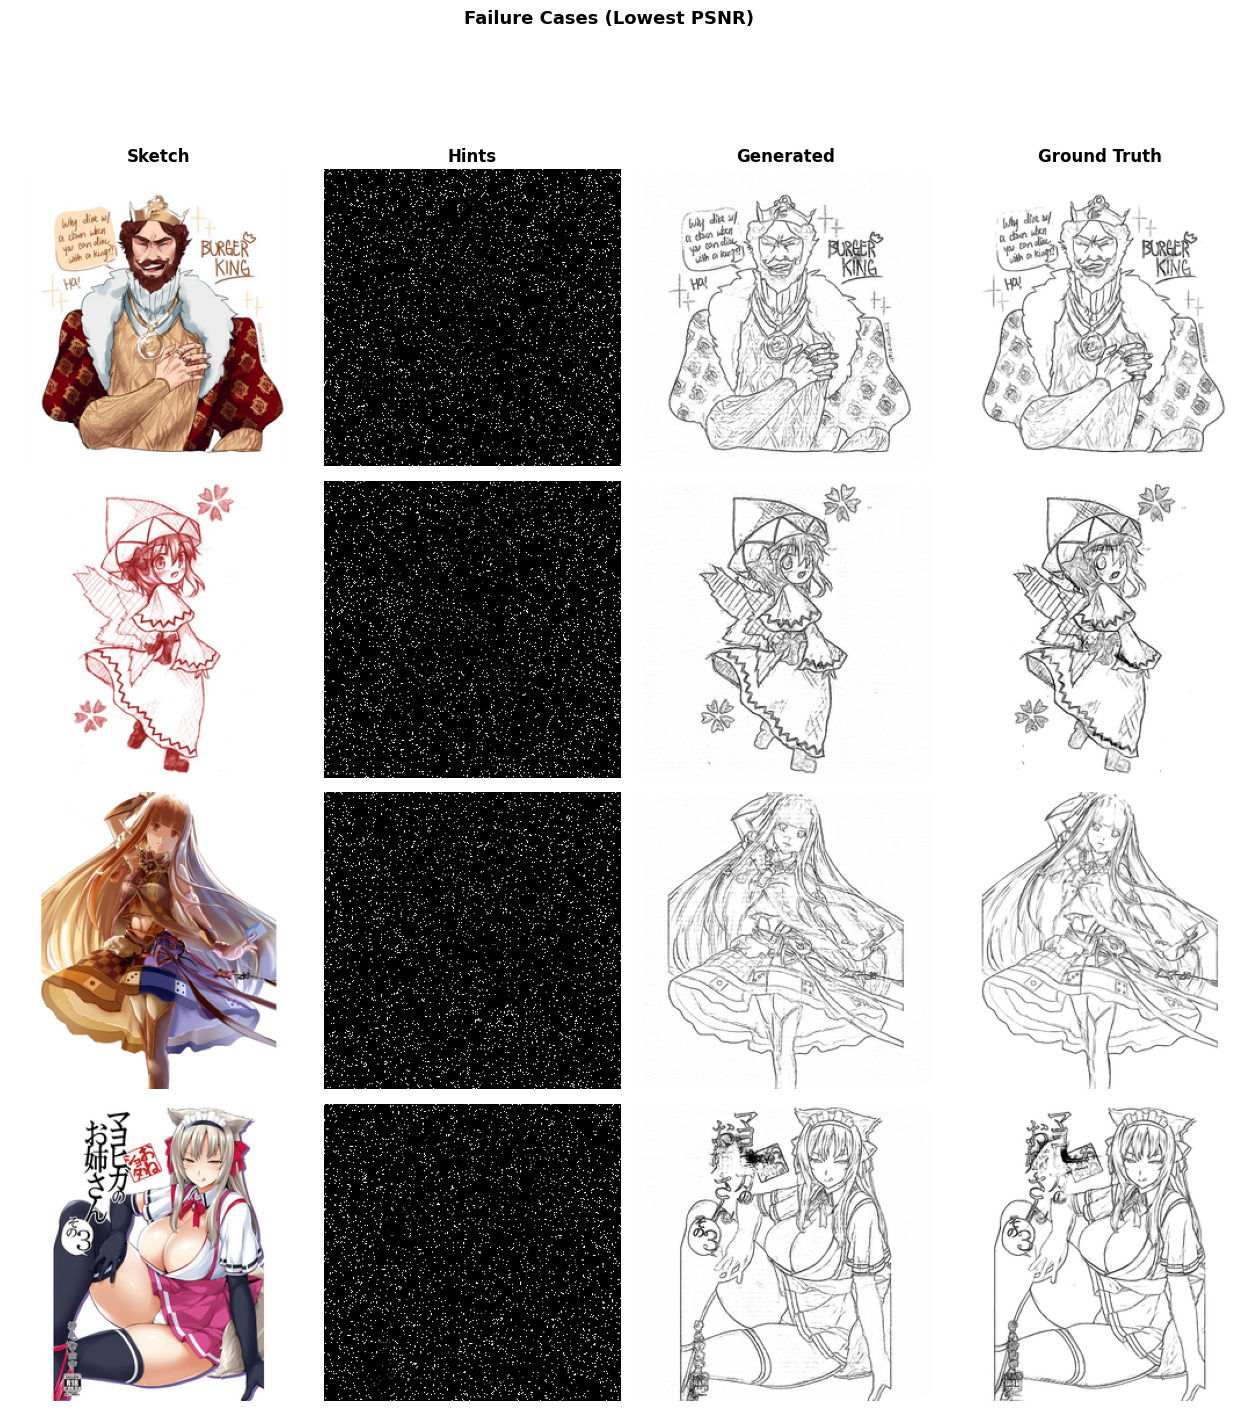

Figures saved to /kaggle/working/figures/


In [21]:
def collect_results(G, dataset, device, max_images=40):
    loader = DataLoader(dataset, batch_size=1, shuffle=False)
    results = []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= max_images:
                break
            model_input = batch["input"].to(device)
            target      = batch["target"].to(device)
            sketch, hint_map, name = batch["sketch"], batch["hint_map"], batch["name"][0]
            generated = G(model_input)

            gen_np = denormalise(generated[0]); tgt_np = denormalise(target[0])
            p = psnr_fn(tgt_np, gen_np, data_range=255)
            s = ssim_fn(tgt_np, gen_np, data_range=255, channel_axis=2)

            results.append({
                "name": name, "sketch_np": denormalise(sketch[0]), "hint_np": denormalise(hint_map[0]),
                "generated_np": gen_np, "target_np": tgt_np, "psnr": p, "ssim": s,
            })
    return results


results = collect_results(G, test_dataset, device, max_images=40)


def save_grid(results, path, n=8, title="Results"):
    n = min(n, len(results))
    fig, axes = plt.subplots(n, 4, figsize=(16, n * 4), gridspec_kw={"hspace": 0.05, "wspace": 0.05})
    if n == 1: axes = [axes]
    titles = ["Sketch", "Hints", "Generated", "Ground Truth"]
    for c, t in enumerate(titles):
        axes[0][c].set_title(t, fontsize=12, fontweight="bold")
    for r, res in enumerate(results[:n]):
        imgs = [res["sketch_np"], res["hint_np"], res["generated_np"], res["target_np"]]
        for c, img in enumerate(imgs):
            axes[r][c].imshow(img); axes[r][c].axis("off")
        axes[r][0].set_ylabel(f"PSNR:{res['psnr']:.1f}\nSSIM:{res['ssim']:.3f}",
                               fontsize=8, rotation=0, labelpad=45, va="center")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()


save_grid(results, os.path.join(FIGURE_DIR, "results_grid.png"), n=8, title="Test Results")

sorted_results = sorted(results, key=lambda x: x["psnr"], reverse=True)
save_grid(sorted_results[:4], os.path.join(FIGURE_DIR, "best_cases.png"), n=4, title="Best Cases (Highest PSNR)")
save_grid(sorted_results[-4:], os.path.join(FIGURE_DIR, "failure_cases.png"), n=4, title="Failure Cases (Lowest PSNR)")

print("Figures saved to /kaggle/working/figures/")


## 16. Hint Density Comparison

Shows the effect of the conditioning mechanism: same sketch, increasing
colour hint coverage (0%, 1%, 5%, 10%, 20%).

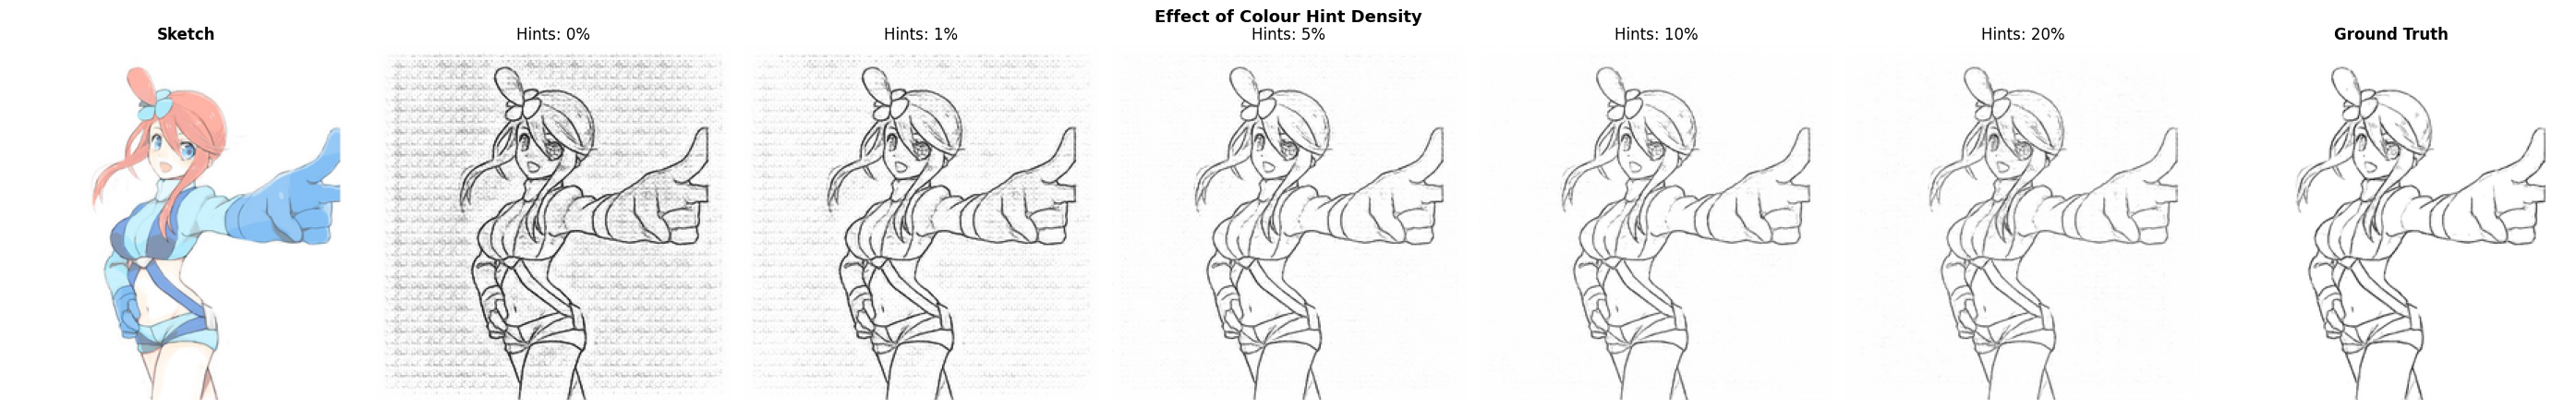

In [22]:
hint_rates  = [0.0, 0.01, 0.05, 0.10, 0.20]
rate_labels = ["0%", "1%", "5%", "10%", "20%"]

sample = test_dataset[0]
sketch_np = denormalise(sample["sketch"])
colour_np = denormalise(sample["target"])

fig, axes = plt.subplots(1, len(hint_rates) + 2, figsize=(4 * (len(hint_rates) + 2), 4.5))
axes[0].imshow(sketch_np); axes[0].set_title("Sketch", fontweight="bold"); axes[0].axis("off")

with torch.no_grad():
    for i, (rate, label) in enumerate(zip(hint_rates, rate_labels)):
        H, W = IMAGE_SIZE, IMAGE_SIZE
        n_hints = max(1, int(H * W * rate)) if rate > 0 else 0
        hint_map  = np.zeros_like(colour_np)
        hint_mask = np.zeros((H, W), dtype=np.float32)
        if n_hints > 0:
            idx = np.random.choice(H * W, size=n_hints, replace=False)
            rows, cols = idx // W, idx % W
            hint_map[rows, cols, :] = colour_np[rows, cols, :]
            hint_mask[rows, cols]   = 1.0

        sketch_t   = sample["sketch"].unsqueeze(0).to(device)
        hint_map_t = torch.from_numpy((hint_map/127.5 - 1.0).transpose(2,0,1)).float().unsqueeze(0).to(device)
        mask_t     = torch.from_numpy(hint_mask[np.newaxis,:,:]).float().unsqueeze(0).to(device)
        model_in   = torch.cat([sketch_t, hint_map_t, mask_t], dim=1)

        gen = G(model_in)
        axes[i+1].imshow(denormalise(gen[0])); axes[i+1].set_title(f"Hints: {label}"); axes[i+1].axis("off")

axes[-1].imshow(colour_np); axes[-1].set_title("Ground Truth", fontweight="bold"); axes[-1].axis("off")
fig.suptitle("Effect of Colour Hint Density", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "hint_density_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()


## 17. Package Everything for Download

Zips checkpoints, logs, and figures into one file in `/kaggle/working/`, which
appears in the **Output** tab and can be downloaded after committing this notebook.

In [23]:
zip_path = "/kaggle/working/sketch_colourisation_results"
shutil.make_archive(zip_path, "zip", root_dir=OUTPUT_ROOT, base_dir=".")

print(f"Archive created: {zip_path}.zip")
print("\nTo download: Commit this notebook (Save Version), then open the")
print("'Output' tab on the notebook's page and download the zip file.")

print("\n--- Contents of /kaggle/working ---")
for root, dirs, files in os.walk(OUTPUT_ROOT):
    level = root.replace(OUTPUT_ROOT, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{indent}  {f}")


Archive created: /kaggle/working/sketch_colourisation_results.zip

To download: Commit this notebook (Save Version), then open the
'Output' tab on the notebook's page and download the zip file.

--- Contents of /kaggle/working ---
working/
  sketch_colourisation_results.zip
  loss_curves.png
  dataset_sample_check.png
  logs/
    training_losses.csv
  checkpoints/
    epoch_0010.pth
    epoch_0005.pth
    final_model.pth
  evaluation/
    metrics_test.csv
    summary_test.txt
    real/
      2518127.png
      2247035.png
      2856100.png
      1497071.png
      2918131.png
    generated/
      2518127.png
      2247035.png
      2856100.png
      1497071.png
      2918131.png
  figures/
    hint_density_comparison.png
    results_grid.png
    failure_cases.png
    best_cases.png
  .virtual_documents/
    __notebook_source__.ipynb
  samples/
    epoch_0010.png
    epoch_0006.png
    epoch_0004.png
    epoch_0002.png
    epoch_0001.png


## 18. Resuming Training in a New Session

Kaggle GPU sessions are time-limited. If training stopped early due to
`TRAIN_TIME_LIMIT_HOURS`, do this to continue:

1. Commit this notebook (**Save Version**) so your `checkpoints/` folder becomes
   part of this notebook's **Output**.
2. Start a **new session** of this same notebook (or copy it).
3. Click **+ Add Data** → **Notebook Output Files** → select this notebook's
   previous version → this mounts your checkpoints under `/kaggle/input/.../checkpoints/`.
4. Add a cell near the top to copy them into the working checkpoint folder before
   the "Build Models" cell runs:

```python
import shutil
prev_ckpt_dir = "/kaggle/input/<your-notebook-output-name>/checkpoints"
if os.path.exists(prev_ckpt_dir):
    for f in os.listdir(prev_ckpt_dir):
        shutil.copy(os.path.join(prev_ckpt_dir, f), CHECKPOINT_DIR)
    print("Previous checkpoints copied. Training will resume automatically.")
```

5. Re-run all cells. The "Build Models" cell automatically detects and resumes
   from the latest checkpoint found in `CHECKPOINT_DIR`.
